# Goal

Assess **single ligand coefficient** HDBSCAN cluster stability across (1) different numbers of variable genes as input and (2) different gene expression level cutoffs.

**`_unique` variant**: a subset of ligand-linker conditions were tested in both well-position orders (e.g. both `IL4_linker` and `linker_IL4`). Before any HVG selection or clustering, swapped-order duplicates are averaged together under one canonical, alphabetically-sorted label (e.g. `IL4_linker`), so each biological condition contributes exactly one row regardless of how many well-position orders were tested.

# Approach

- **Input to the HDBSCAN algorithm is a ligand-condition x genes matrix of GLM ligand coefficient values.**
    - HDBSCAN clustering is performed using the following parameters: min_cluster_size=2, min_samples=1, metric='correlation'.
    - Only linker-containing conditions are used as input into clustering.

- **Cluster stability is assessed by bootstrapping over 2000 iterations.**
    - In each bootstrap, gene columns are randomly sampled with replacement.
    - HDBSCAN is run on the re-sampled data.
    - Stability is assessed by adjusted rand index of clustering across bootstraps in comparison to the non-bootstrapped reference.

# Import

Load coefficient files and the significant single-term LFC files used for highly-variable-gene selection (linker-containing conditions).

In [1]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"

import os
import numpy as np
import pandas as pd
import hdbscan
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import sys
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

In [2]:
base_dir = f'{IMPORTS_DIR}/SIG13/analysis_outs'  # upstream inputs
out_dir = OUTS_DIR  # outputs of this notebook
plots_dir = f'{out_dir}/clustering/plots'
os.makedirs(plots_dir, exist_ok=True)

REF_FILTER = '0.2filter'
REF_N_GENES = 3000

def canonicalize_pair(name, sep='_'):
    """Collapse swapped well-position order (e.g. 'IL4_linker' / 'linker_IL4') to one
    canonical, alphabetically-sorted label."""
    a, b = name.split(sep)
    return sep.join(sorted([a, b]))

# Replicate correlation for consistent_ligands filter (0.2filter used for all conditions),
# with swapped well-position order pairs averaged together before thresholding, matching
# the canonicalization applied to coeff_dfs/sigLfc_dfs below.
singleRepCor = pd.read_csv(f'{base_dir}/replicate_corr/replicate_correlation_singleLfc_0.2filter.csv')
singleRepCor['canonical'] = singleRepCor['condition'].apply(canonicalize_pair)
singleRepCor_avg = (
    singleRepCor
    .groupby('canonical')[['pearson_corr', 'num_shared_genes']]
    .mean()
    .reset_index()
    .rename(columns={'canonical': 'condition'})
)
consistent_ligands = singleRepCor_avg[
    (singleRepCor_avg['pearson_corr'] > 0.25) & (singleRepCor_avg['num_shared_genes'] > 1)
]['condition'].tolist()
print(f'Consistent ligands (order-pairs averaged): {len(consistent_ligands)}')

# Load coefficient files for all eight filter cutoffs (all real, independently-fit glmGamPoi runs)
FILTER_CUTOFFS = ['0.05filter', '0.1filter', '0.15filter', '0.2filter', '0.25filter', '0.3filter', '0.35filter', '0.4filter']
coeff_files = {c: f'{base_dir}/glmGamPoi/glmGamPoi_singleTerm_coefficients_{c}.csv' for c in FILTER_CUTOFFS}
coeff_dfs_raw = {k: pd.read_csv(v) for k, v in coeff_files.items()}
print('Coefficient files loaded.')
for k, df in coeff_dfs_raw.items():
    n_linker = df[df['condition'].astype(str).str.contains('linker', case=False, na=False)]['condition'].nunique()
    print(f'  {k}: {df.shape[0]:,} rows, {n_linker} linker conditions, cols: {list(df.columns)}')

# Restrict to linker-containing conditions and average swapped well-position orders
# together (e.g. IL4_linker / linker_IL4) under one canonical label, per gene.
coeff_numeric_cols = ['Intercept', 'ligand', 'replicaterep2', 'lane2', 'percent.mito', 's.score', 'g2m.score']
coeff_dfs = {}
for k, df in coeff_dfs_raw.items():
    df = df[df['condition'].astype(str).str.contains('linker', case=False, na=False)].copy()
    df['canonical'] = df['condition'].apply(canonicalize_pair)
    df_avg = (
        df.groupby(['canonical', 'name'])[coeff_numeric_cols]
        .mean()
        .reset_index()
        .rename(columns={'canonical': 'condition'})
    )
    coeff_dfs[k] = df_avg
    print(f'  {k}: {df["condition"].nunique():,} linker conditions -> {df_avg["condition"].nunique():,} canonical conditions')

# Load significant single-term LFC files for all eight filter cutoffs (used for HVG
# selection via variance of lfc, restricted to linker-containing conditions)
sigLfc_files = {c: f'{base_dir}/glmGamPoi/glmGamPoi_singleTerm_lfc_sig_{c}.csv' for c in FILTER_CUTOFFS}
sigLfc_dfs_raw = {k: pd.read_csv(v) for k, v in sigLfc_files.items()}
print('Significant single-term LFC files loaded.')
for k, df in sigLfc_dfs_raw.items():
    print(f'  {k}: {df.shape[0]:,} rows, cols: {list(df.columns)}')

# Restrict to linker-containing conditions and average swapped well-position orders
# together before HVG selection.
sigLfc_dfs = {}
for k, df in sigLfc_dfs_raw.items():
    df = df[df['condition'].astype(str).str.contains('linker', case=False, na=False)].copy()
    df['canonical'] = df['condition'].apply(canonicalize_pair)
    df_avg = (
        df.groupby(['canonical', 'name'])['lfc']
        .mean()
        .reset_index()
        .rename(columns={'canonical': 'condition'})
    )
    sigLfc_dfs[k] = df_avg
    print(f'  {k}: {df["condition"].nunique():,} linker conditions -> {df_avg["condition"].nunique():,} canonical conditions')

Consistent ligands (order-pairs averaged): 500


Coefficient files loaded.


  0.05filter: 5,784,239 rows, 65 linker conditions, cols: ['name', 'Intercept', 'ligand', 'replicaterep2', 'lane2', 'percent.mito', 's.score', 'g2m.score', 'condition']


  0.1filter: 5,229,253 rows, 65 linker conditions, cols: ['name', 'Intercept', 'ligand', 'replicaterep2', 'lane2', 'percent.mito', 's.score', 'g2m.score', 'condition']


  0.15filter: 4,735,479 rows, 65 linker conditions, cols: ['name', 'Intercept', 'ligand', 'replicaterep2', 'lane2', 'percent.mito', 's.score', 'g2m.score', 'condition']


...

  0.2filter: 65 linker conditions -> 54 canonical conditions


  0.25filter: 65 linker conditions -> 54 canonical conditions


  0.3filter: 65 linker conditions -> 54 canonical conditions


  0.35filter: 65 linker conditions -> 54 canonical conditions


  0.4filter: 65 linker conditions -> 54 canonical conditions


# Helper Functions

In [3]:
def build_wide_mat(coeff_df, sigLfc_df, n_genes, lfc_col='ligand'):
    """Pivot coefficient df to (conditions x genes) matrix, using the top n_genes by
    variance of lfc in the significant single-term LFC file, restricted to linker-containing,
    replicate-consistent conditions."""
    genes_selected = (
        sigLfc_df
        .loc[sigLfc_df['condition'].astype(str).str.contains('linker', case=False, na=False)]
        .loc[sigLfc_df['condition'].isin(consistent_ligands)]
        .groupby('name')['lfc']
        .var()
        .nlargest(n_genes)
        .index.tolist()
    )
    df = coeff_df[coeff_df['condition'].astype(str).str.contains('linker', case=False, na=False)].copy()
    df = df[df['condition'].isin(consistent_ligands)]
    df = df[df['name'].isin(genes_selected)]
    return df.pivot_table(index='condition', columns='name', values=lfc_col, fill_value=0)


def run_hdbscan(mat, min_cluster_size=2, min_samples=1, metric='correlation'):
    """Run HDBSCAN and return cluster labels array."""
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric
    )
    return clusterer.fit_predict(mat.values)


def align_labels(ref, boot):
    """
    Remap boot cluster IDs to maximally overlap with ref using the Hungarian
    algorithm. Required because HDBSCAN does not guarantee consistent cluster
    numbering across runs — raw label comparison is meaningless without this.
    Noise points (-1) are kept as -1 and not remapped.
    """
    ref, boot = np.asarray(ref), np.asarray(boot)
    ref_clusters  = np.unique(ref[ref   != -1])
    boot_clusters = np.unique(boot[boot != -1])

    if len(ref_clusters) == 0 or len(boot_clusters) == 0:
        return boot.copy()

    # Overlap matrix: how many points each (ref_cluster, boot_cluster) pair shares
    overlap = np.array([
        [((ref == rc) & (boot == bc)).sum() for bc in boot_clusters]
        for rc in ref_clusters
    ])
    # linear_sum_assignment natively handles rectangular matrices, matching
    # min(n_ref_clusters, n_boot_clusters) pairs — no manual padding needed.
    row_ind, col_ind = linear_sum_assignment(-overlap)

    mapping = {-1: -1}
    for i, j in zip(row_ind, col_ind):
        mapping[boot_clusters[j]] = ref_clusters[i]
    # Boot clusters with no ref match keep their original label
    return np.array([mapping.get(lbl, lbl) for lbl in boot])


def masked_ari(labels_a, labels_b, exclude_noise=False):
    """
    ARI between two label arrays. If exclude_noise=True, points assigned -1
    (noise) in either clustering are removed before scoring.
    """
    labels_a, labels_b = np.asarray(labels_a), np.asarray(labels_b)
    if exclude_noise:
        mask = (labels_a != -1) & (labels_b != -1)
        if mask.sum() < 2:
            return np.nan
        labels_a, labels_b = labels_a[mask], labels_b[mask]
    return adjusted_rand_score(labels_a, labels_b)


def bootstrap_gene_stability(wide_mat, n_bootstrap=100, frac=1.0, seed=42,
                              min_cluster_size=2, min_samples=1, exclude_noise=False,
                              return_label_matrix=False):
    """
    Bootstrap gene columns, rerun HDBSCAN, compute ARI vs. reference clustering
    on the full gene set, and record the number of clusters (excl. noise) found
    in each bootstrap iteration. Returns (ari_scores, n_clusters_boot, ref_labels)
    or, when return_label_matrix=True, (ari_scores, n_clusters_boot, ref_labels,
    label_df) where label_df is a DataFrame of shape (n_conditions x n_bootstrap)
    with each iteration's cluster assignments.
    exclude_noise: if True, noise points (-1) are removed before ARI computation.
    """
    ref_labels = run_hdbscan(wide_mat, min_cluster_size, min_samples)
    n_genes = wide_mat.shape[1]
    n_sample = int(n_genes * frac)
    rng = np.random.default_rng(seed)
    ari_scores = []
    n_clusters_boot = []
    label_matrix = [] if return_label_matrix else None
    for _ in range(n_bootstrap):
        # sample with replacement
        idx = rng.choice(n_genes, size=n_sample, replace=True)
        boot_labels = run_hdbscan(wide_mat.iloc[:, idx], min_cluster_size, min_samples)
        ari_scores.append(masked_ari(ref_labels, boot_labels, exclude_noise=exclude_noise))
        n_clusters_boot.append(len(np.unique(boot_labels[boot_labels != -1])))
        if return_label_matrix:
            label_matrix.append(boot_labels)
    if return_label_matrix:
        label_df = pd.DataFrame(
            np.column_stack(label_matrix),
            index=wide_mat.index,
            columns=range(n_bootstrap)
        )
        return ari_scores, n_clusters_boot, ref_labels, label_df
    return ari_scores, n_clusters_boot, ref_labels

# HDBSCAN Cluster Stability: Bootstrap Gene Resampling (Single Ligand)

Tests HDBSCAN clustering stability by bootstrapping gene subsets and computing adjusted rand index (ARI) against a reference clustering. For each gene count / filter cutoff swept, the reference is generated fresh on that setting's own data, so stability is assessed within each setting rather than against a single global reference.

## Stability Across Variable Gene Counts

For each gene count, a fresh HDBSCAN reference is generated on that gene count's own wide matrix, and bootstrap ARI is computed against that reference — assessing whether clustering is less stable at lower numbers of variable genes.

In [4]:
%%time
gene_counts = [100, 500, 1000, 2000, 3000, 4000, 5000, 6000]

results_ngenes = {}  # n_genes -> list of bootstrap ARI scores (vs. that n_genes' own reference)
n_clusters_ngenes = {}  # n_genes -> list of bootstrap cluster counts (excl. noise)

for n_genes in gene_counts:
    print(f'n_genes={n_genes}...', end=' ')
    wide_mat = build_wide_mat(coeff_dfs[REF_FILTER], sigLfc_dfs[REF_FILTER], n_genes)
    ari_boot, n_clusters_boot, ref_labels = bootstrap_gene_stability(wide_mat, n_bootstrap=2000, frac=1.0)
    results_ngenes[n_genes] = ari_boot
    n_clusters_ngenes[n_genes] = n_clusters_boot
    print(f'median ARI={np.median(ari_boot):.3f}, median n_clusters={np.median(n_clusters_boot):.1f}')

print('Done.')

n_genes=100... 

median ARI=0.707, median n_clusters=7.0
n_genes=500... 

median ARI=0.863, median n_clusters=7.0
n_genes=1000... 

median ARI=0.863, median n_clusters=8.0
n_genes=2000... 

median ARI=0.908, median n_clusters=8.0
n_genes=3000... 

median ARI=0.889, median n_clusters=8.0
n_genes=4000... 

median ARI=0.878, median n_clusters=8.0
n_genes=5000... 

median ARI=0.881, median n_clusters=8.0
n_genes=6000... 

median ARI=0.889, median n_clusters=8.0
Done.
CPU times: user 51 s, sys: 60.9 ms, total: 51.1 s
Wall time: 51.4 s


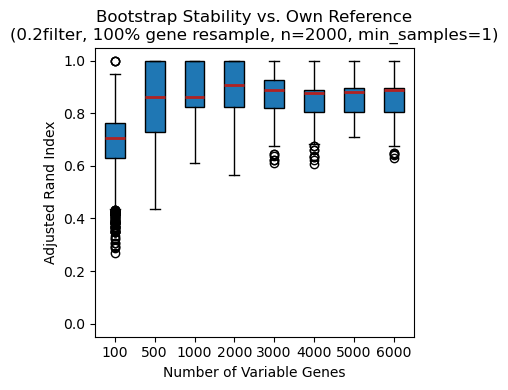

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))

# Boxplot: bootstrap ARI within each gene count's own reference
data_box = [results_ngenes[n] for n in gene_counts]
bp = ax.boxplot(data_box, patch_artist=True,
                medianprops=dict(color='firebrick', linewidth=2))
ax.set_xticklabels(gene_counts)
ax.set_xlabel('Number of Variable Genes')
ax.set_ylabel('Adjusted Rand Index')
ax.set_title(f'Bootstrap Stability vs. Own Reference\n({REF_FILTER}, 100% gene resample, n=2000, min_samples=1)')
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
fig.savefig(f'{plots_dir}/bootstrap_ari_ngenes_singleLigand_minSamples1_unique.pdf', bbox_inches='tight')
plt.show()

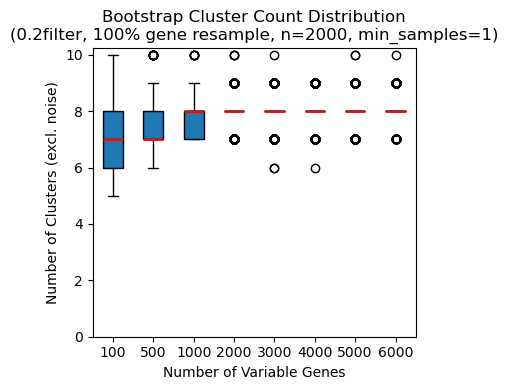

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))

# Boxplot: bootstrap cluster count (excl. noise) within each gene count's own bootstrap runs
data_box_nclusters = [n_clusters_ngenes[n] for n in gene_counts]
bp = ax.boxplot(data_box_nclusters, patch_artist=True,
                medianprops=dict(color='firebrick', linewidth=2))
ax.set_xticklabels(gene_counts)
ax.set_ylim(bottom=0)
ax.set_xlabel('Number of Variable Genes')
ax.set_ylabel('Number of Clusters (excl. noise)')
ax.set_title(f'Bootstrap Cluster Count Distribution\n({REF_FILTER}, 100% gene resample, n=2000, min_samples=1)')

plt.tight_layout()
fig.savefig(f'{plots_dir}/n_clusters_ngenes_singleLigand_minSamples1_unique.pdf', bbox_inches='tight')
plt.show()

## Stability Across Filter Cutoffs

Same bootstrap approach, varying the expression filter cutoff (0.05 - 0.4, step 0.05). Each cutoff is a real, independently-fit `glmGamPoi` run (`analysis/interaction_scoring/glmGamPoi_single_term_slurm.r`, re-run on SLURM for 0.15/0.25/0.30/0.35/0.40 alongside the original 0.05/0.1/0.2), so coefficients and dispersion estimates are genuinely recalibrated at each cutoff rather than reused from a single base fit. Order-pair averaging (see Import cell above) is applied identically to all eight cutoffs. For each cutoff, a fresh HDBSCAN reference is generated on that cutoff's own wide matrix, and bootstrap ARI is computed against that reference — assessing whether different cutoffs lead to less stable clusters. All use linker conditions and `REF_N_GENES` variable genes.

In [7]:
%%time
filters = ['0.05filter', '0.1filter', '0.15filter', '0.2filter', '0.25filter', '0.3filter', '0.35filter', '0.4filter']

results_filters = {}  # filter -> list of bootstrap ARI scores (vs. that filter's own reference)
n_clusters_filters = {}  # filter -> list of bootstrap cluster counts (excl. noise)

for filt in filters:
    print(f'{filt}...', end=' ')
    wide_mat = build_wide_mat(coeff_dfs[filt], sigLfc_dfs[filt], REF_N_GENES)
    ari_boot, n_clusters_boot, ref_labels = bootstrap_gene_stability(wide_mat, n_bootstrap=2000, frac=1.0)
    results_filters[filt] = ari_boot
    n_clusters_filters[filt] = n_clusters_boot
    print(f'median ARI={np.median(ari_boot):.3f}, median n_clusters={np.median(n_clusters_boot):.1f}')

print('Done.')

0.05filter... 

median ARI=0.814, median n_clusters=8.0
0.1filter... 

median ARI=0.822, median n_clusters=8.0
0.15filter... 

median ARI=0.889, median n_clusters=8.0
0.2filter... 

median ARI=0.889, median n_clusters=8.0
0.25filter... 

median ARI=0.806, median n_clusters=8.0
0.3filter... 

median ARI=0.848, median n_clusters=8.0
0.35filter... 

median ARI=0.796, median n_clusters=8.0
0.4filter... 

median ARI=0.810, median n_clusters=8.0
Done.
CPU times: user 52.3 s, sys: 55.5 ms, total: 52.3 s
Wall time: 52.6 s


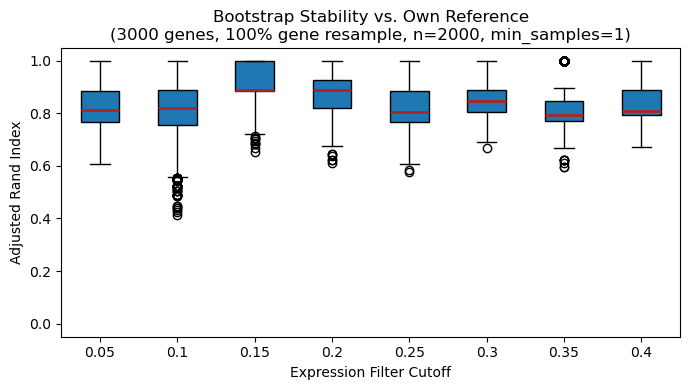

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

filter_labels = ['0.05', '0.1', '0.15', '0.2', '0.25', '0.3', '0.35', '0.4']

# Boxplot: bootstrap ARI within each filter's own reference
data_box_f = [results_filters[f] for f in filters]
bp = ax.boxplot(data_box_f, patch_artist=True,
                medianprops=dict(color='firebrick', linewidth=2))
ax.set_xticklabels(filter_labels)
ax.set_xlabel('Expression Filter Cutoff')
ax.set_ylabel('Adjusted Rand Index')
ax.set_title(f'Bootstrap Stability vs. Own Reference\n({REF_N_GENES} genes, 100% gene resample, n=2000, min_samples=1)')
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
fig.savefig(f'{plots_dir}/bootstrap_ari_filters_singleLigand_minSamples1_unique.pdf', bbox_inches='tight')
plt.show()

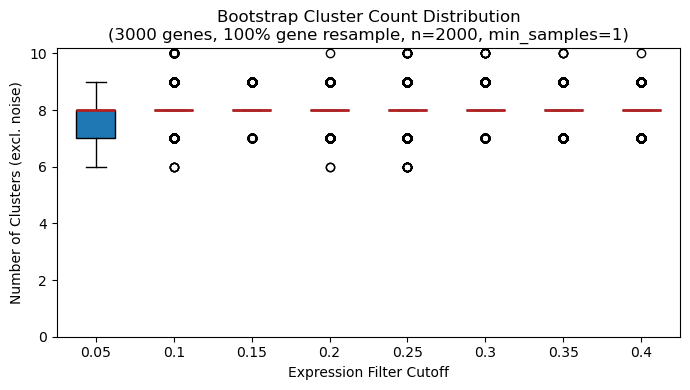

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

filter_labels = ['0.05', '0.1', '0.15', '0.2', '0.25', '0.3', '0.35', '0.4']

# Boxplot: bootstrap cluster count (excl. noise) within each filter's own bootstrap runs
data_box_nclusters_f = [n_clusters_filters[f] for f in filters]
bp = ax.boxplot(data_box_nclusters_f, patch_artist=True,
                medianprops=dict(color='firebrick', linewidth=2))
ax.set_xticklabels(filter_labels)
ax.set_ylim(bottom=0)
ax.set_xlabel('Expression Filter Cutoff')
ax.set_ylabel('Number of Clusters (excl. noise)')
ax.set_title(f'Bootstrap Cluster Count Distribution\n({REF_N_GENES} genes, 100% gene resample, n=2000, min_samples=1)')

plt.tight_layout()
fig.savefig(f'{plots_dir}/n_clusters_filters_singleLigand_minSamples1_unique.pdf', bbox_inches='tight')
plt.show()

# Final Clustering

Generate the canonical HDBSCAN reference clustering at `REF_FILTER`/`REF_N_GENES` (linker conditions only), export cluster membership, and assess bootstrap stability at these reference parameters.

**Final params**: 0.2filter coefficients, 4000 variable genes, min_cluster_size=2, min_samples=1, metric='correlation'

In [10]:
# Build reference wide matrix and run reference clustering
ref_wide_mat = build_wide_mat(coeff_dfs[REF_FILTER], sigLfc_dfs[REF_FILTER], REF_N_GENES)
ref_labels = run_hdbscan(ref_wide_mat)

print(f'Reference wide_mat shape: {ref_wide_mat.shape}')
unique, counts = np.unique(ref_labels, return_counts=True)
print('Reference cluster distribution:')
for u, c in zip(unique, counts):
    label = 'noise' if u == -1 else f'cluster {u}'
    print(f'  {label}: {c} conditions')

# Cluster membership table
ref_cluster_df = pd.DataFrame({'cluster': ref_labels}, index=ref_wide_mat.index)
ref_cluster_df.index.name = 'condition'
ref_cluster_df = ref_cluster_df.sort_values('cluster')
display(ref_cluster_df)

out_path = f'{out_dir}/clustering/hdbscan_ref_clusters_singleLigand_minSamples1_unique.csv'
ref_cluster_df.to_csv(out_path)
print(f'Cluster membership saved to: {out_path}')

Reference wide_mat shape: (29, 3000)
Reference cluster distribution:
  noise: 4 conditions
  cluster 0: 2 conditions
  cluster 1: 5 conditions
  cluster 2: 2 conditions
  cluster 3: 5 conditions
  cluster 4: 4 conditions
  cluster 5: 2 conditions
  cluster 6: 2 conditions
  cluster 7: 3 conditions


,cluster
condition,
IL1F8_linker,-1
IFNE_linker,-1
IL9_linker,-1
TGFB1_linker,-1
CCL20_linker,0
IL23_linker,0
CXCL10_linker,1
CCL11_linker,1
IL25_linker,1


Cluster membership saved to: /data1/rudenska/EYW/git_projects/SIG13/analysis_outs/clustering/hdbscan_ref_clusters_singleLigand_minSamples1_unique.csv


### Bootstrap Stability — Final Clustering

1000 bootstrap iterations with 100% gene subsets. ARI computed against the reference clustering above. Clusters are matched between bootstrap runs using scipy implementation linear_sum_assignment.

In [11]:
print('Running bootstrap (5000 iterations, 100% gene subset)...')
ari_ref, _, _, label_mat_ref = bootstrap_gene_stability(
    ref_wide_mat, n_bootstrap=5000, frac=1.0, seed=42, return_label_matrix=True
)
print(f'Done. Median ARI: {np.median(ari_ref):.3f} | 5th pct: {np.percentile(ari_ref, 5):.3f}')

Running bootstrap (5000 iterations, 100% gene subset)...


Done. Median ARI: 0.889 | 5th pct: 0.756


In [12]:
# Display and export bootstrap ARI scores
ari_ref_df = pd.DataFrame({'ari': ari_ref})
ari_ref_df.index.name = 'bootstrap_iter'
print('Bootstrap ARI summary:')
display(ari_ref_df.describe().round(4))

Bootstrap ARI summary:


,ari
count,5000.0000
mean,0.8801
std,0.0787
min,0.6110
25%,0.8216
50%,0.8891
75%,0.9283
max,1.0000


In [13]:
# Per-condition cluster variability across bootstrap iterations.
# Each bootstrap run's labels are first aligned to the reference via the
# scipy.linear_sum_assignment to correct for HDBSCAN's arbitrary cluster numbering,
# so that a mismatch reflects a genuine reassignment, not a label permutation.
label_arr = label_mat_ref.values  # (n_conditions, n_bootstrap)

aligned_arr = np.column_stack([
    align_labels(ref_labels, label_arr[:, i])
    for i in range(label_arr.shape[1])
])  # (n_conditions, n_bootstrap), IDs remapped to ref numbering

var_df = pd.DataFrame(index=ref_wide_mat.index)
var_df.index.name = 'condition'
var_df['ref_cluster']       = ref_labels
var_df['frac_mismatch']     = np.mean(aligned_arr != ref_labels[:, None], axis=1)
var_df['n_unique_clusters'] = [len(np.unique(row)) for row in aligned_arr]
var_df['modal_cluster']     = [pd.Series(row).mode()[0] for row in aligned_arr]
var_df = var_df.sort_values('frac_mismatch', ascending=False)

# create modal hdbscan df
modal_df = var_df[['modal_cluster']].copy()
modal_df.rename(columns={'modal_cluster': 'cluster'}, inplace=True)

n_unstable = (var_df['frac_mismatch'] > 0).sum()
print(f'{n_unstable} / {len(var_df)} conditions show any cluster instability '
      f'across {label_arr.shape[1]} bootstrap iterations:\n')
display(var_df[var_df['frac_mismatch'] > 0].round(3))

out_path = f'{out_dir}/clustering/hdbscan_bootstrap_cluster_variability_singleLigand_minSamples1_unique.csv'
var_df.to_csv(out_path)
print(f'\nFull variability table saved to: {out_path}')

out_path = f'{out_dir}/clustering/hdbscan_bootstrap_modal_clusters_singleLigand_minSamples1_unique.csv'
modal_df.to_csv(out_path)
print(f'Modal cluster assignments saved to: {out_path}')

9 / 29 conditions show any cluster instability across 5000 bootstrap iterations:



,ref_cluster,frac_mismatch,n_unique_clusters,modal_cluster
condition,,,,
IFNE_linker,-1,0.613,6,-1
CCL7_linker,1,0.245,6,1
CCL11_linker,1,0.144,4,1
CCL20_linker,0,0.090,3,0
CCL22_linker,1,0.081,6,1
IL23_linker,0,0.068,3,0
IL25_linker,1,0.062,5,1
IL1F8_linker,-1,0.057,2,-1
CXCL10_linker,1,0.046,5,1



Full variability table saved to: /data1/rudenska/EYW/git_projects/SIG13/analysis_outs/clustering/hdbscan_bootstrap_cluster_variability_singleLigand_minSamples1_unique.csv
Modal cluster assignments saved to: /data1/rudenska/EYW/git_projects/SIG13/analysis_outs/clustering/hdbscan_bootstrap_modal_clusters_singleLigand_minSamples1_unique.csv


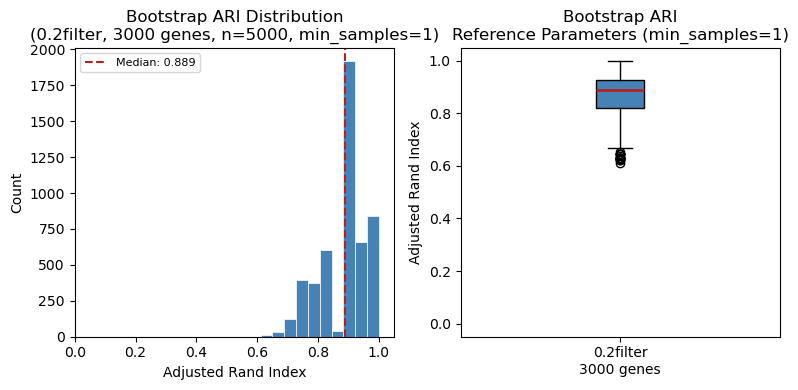

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Histogram
axes[0].hist(ari_ref, bins=10, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(np.median(ari_ref), color='firebrick', linestyle='--', label=f'Median: {np.median(ari_ref):.3f}')
axes[0].set_xlim([0,1.05])
axes[0].set_xlabel('Adjusted Rand Index')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Bootstrap ARI Distribution\n({REF_FILTER}, {REF_N_GENES} genes, n=5000, min_samples=1)')
axes[0].legend(fontsize=8)

# Boxplot
axes[1].boxplot(ari_ref, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue'),
                medianprops=dict(color='firebrick', linewidth=2))
axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_xticklabels([f'{REF_FILTER}\n{REF_N_GENES} genes'])
axes[1].set_title('Bootstrap ARI\nReference Parameters (min_samples=1)')
axes[1].set_ylim([-0.05, 1.05])

plt.tight_layout()
fig.savefig(f'{plots_dir}/bootstrap_ari_ref_params_singleLigand_minSamples1_unique.pdf', bbox_inches='tight')
plt.show()